### Sistema de agrupación de casas.

Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.


### 00. Importar librerias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import pickle

### Paso 1: Carga del conjunto de datos

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre housing.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv
O descargarlo y añadirlo a mano en tu repositorio. 
En este caso solo nos interesan las columnas Latitude, Longitude y MedInc.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores. Aunque estos conjuntos no se utilicen para obtener estadísticas, podrás utilizarlos para entrenar el algoritmo no supervisado y luego para hacer predicciones sobre puntos nuevos para predecir el cluster al que se asocian.



In [3]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
data = pd.read_csv(url)

# En este caso solo nos interesan las columnas Latitude, Longitude y MedInc.
data = data[["Latitude", "Longitude", "MedInc"]]

print("Primeras filas del dataset:")
print(data.head())
print(f"Dimensiones del dataset: {data.shape}")

Primeras filas del dataset:
   Latitude  Longitude  MedInc
0     37.88    -122.23  8.3252
1     37.86    -122.22  8.3014
2     37.85    -122.24  7.2574
3     37.85    -122.25  5.6431
4     37.85    -122.25  3.8462
Dimensiones del dataset: (20640, 3)


### Paso 2: Construye un K-Means
Clasifica los datos en 6 clusters utilizando, para ello, el modelo K-Means. A continuación, almacena el cluster al que pertenece cada casa como una columna nueva del dataset. Podrías llamarla cluster. Para introducirla a tu conjunto de datos quizá tengas que categorizarla. Observa qué formato y valores tiene y actúa en consecuencia. Grafícala en un diagrama de puntos y describe lo que ves.


In [4]:
X_train, X_test = train_test_split(data, test_size=0.2, random_state=42) #separacion del dataset en entrenamiento y prueba
print(f"Dimensiones del set de entrenamiento: {X_train.shape}")
print(f"Dimensiones del set de prueba: {X_test.shape}")

Dimensiones del set de entrenamiento: (16512, 3)
Dimensiones del set de prueba: (4128, 3)


In [5]:
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
kmeans.fit(X_train)

# se guardan los clusters para usarlos en el arbol de decision
X_train = X_train.copy()  # Evita warning de pandas
X_train["Cluster"] = kmeans.labels_

### 2.1 Grafícala en un diagrama de puntos y describe lo que ves.

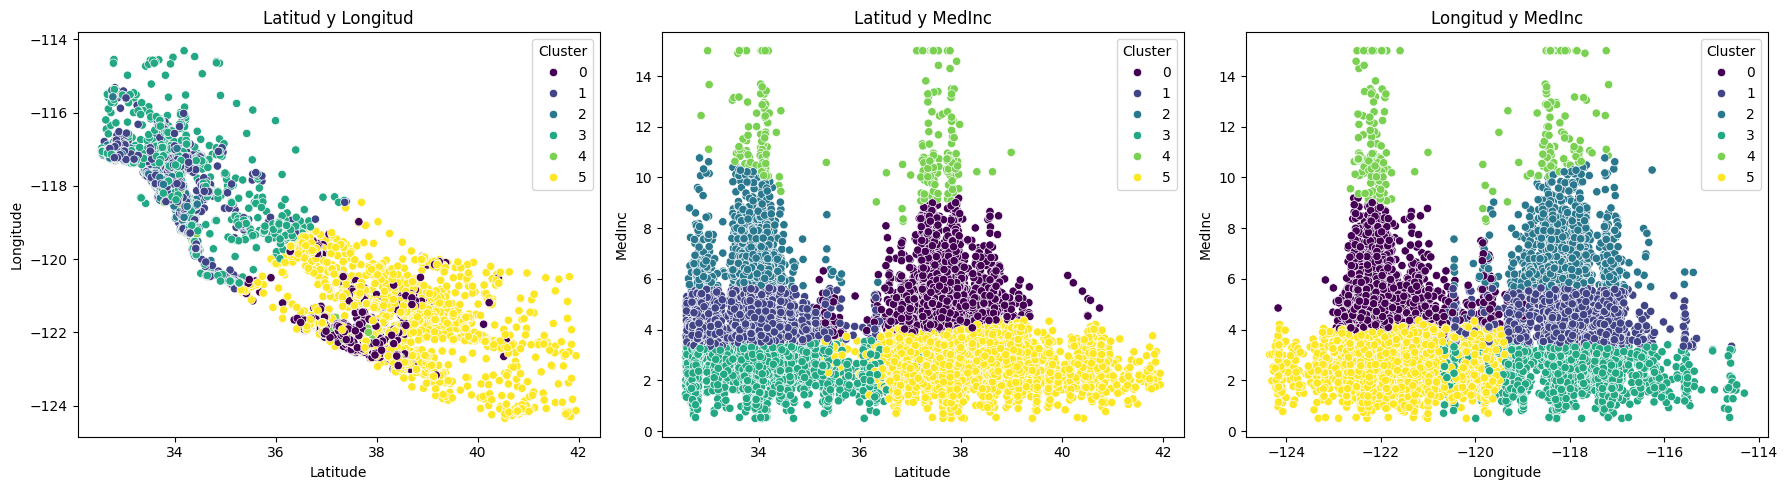

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(ax=axes[0], data=X_train, x="Latitude", y="Longitude", hue="Cluster", palette="viridis")
axes[0].set_title("Latitud y Longitud")

sns.scatterplot(ax=axes[1], data=X_train, x="Latitude", y="MedInc", hue="Cluster", palette="viridis")
axes[1].set_title("Latitud y MedInc")

sns.scatterplot(ax=axes[2], data=X_train, x="Longitude", y="MedInc", hue="Cluster", palette="viridis")
axes[2].set_title("Longitud y MedInc")

plt.tight_layout()
plt.show()

Grafico 1: se observa en este grafico  que los clusters forman regiones geográficas
bien diferenciadas. Cada color representa una zona específica de California, lo
que indica que la UBICACIÓN GEOGRÁFICA es un factor determinante en la agrupación.

Grafico 2: en este segundo gráfico se muestra la relación entre ubicación y nivel económico.
Observamos que algunos clusters se concentran en niveles de ingreso específicos.

Grafico 3: el tercer gráfico revelanos muestra la relación entre la posición Este-Oeste y el nivel
económico. Observamos una tendencia donde hay áreas con valores más negativos
de longitud que  tienden a tener mayores ingresos medios, se ve representado mayor division en esta UBICACION GEOGRAFICA

### Paso 3: Predice con el conjunto de test.

Ahora utiliza el modelo entrenado con el conjunto test y añade los puntos al gráfico anterior para confirmar que la predicción es satisfactoria o no.

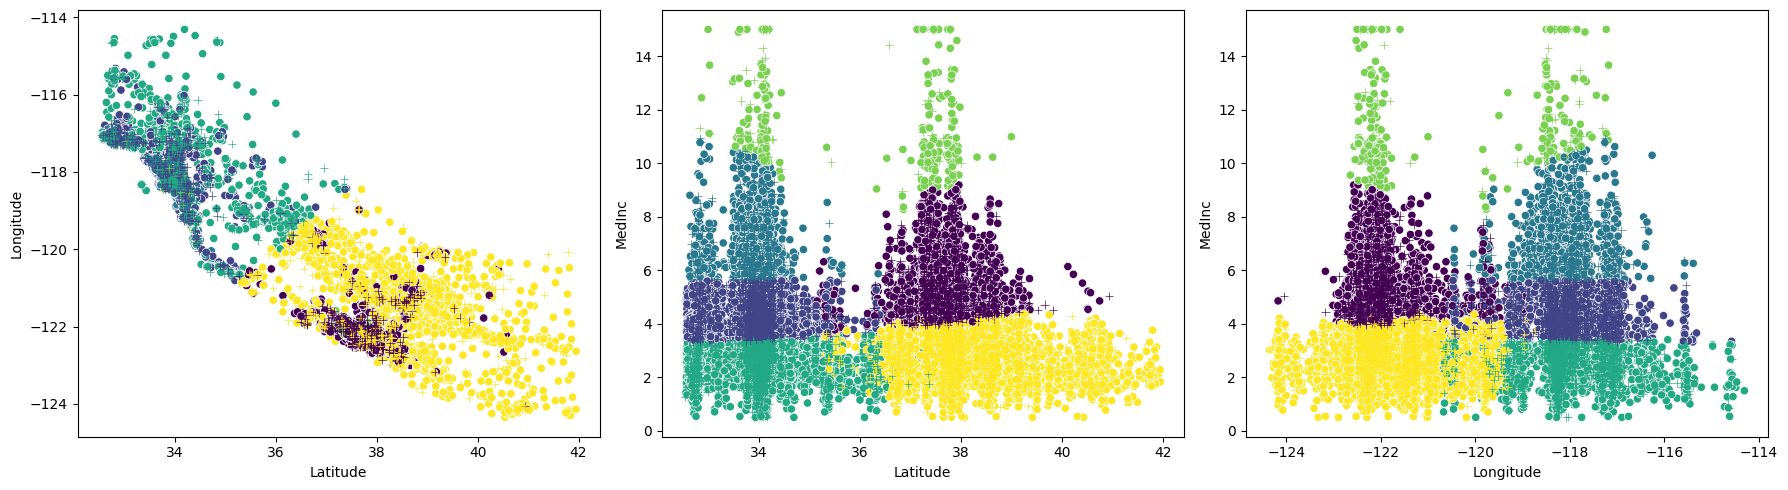

In [7]:
X_test = X_test.copy()
X_test["Cluster"] = kmeans.predict(X_test)

# Añadimos los clusters al set de prueba para visualizarlos
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate([("Latitude","Longitude"), ("Latitude","MedInc"), ("Longitude","MedInc")]):
    sns.scatterplot(ax=axes[i], data=X_train, x=col[0], y=col[1], hue="Cluster", palette="viridis")
    sns.scatterplot(ax=axes[i], data=X_test, x=col[0], y=col[1], hue="Cluster", palette="viridis", marker="+")
    axes[i].legend([],[], frameon=False)

plt.tight_layout()
plt.show()

### Paso 4: Entrena un modelo de clasificación supervisada.

Ahora que el K-Means nos ha devuelto una categorización (agrupación) de los puntos para los conjuntos de entrenamiento y prueba, estudia qué modelo podría ser más útil y entrénalo. Obtén las estadísticas y describe lo que ves.

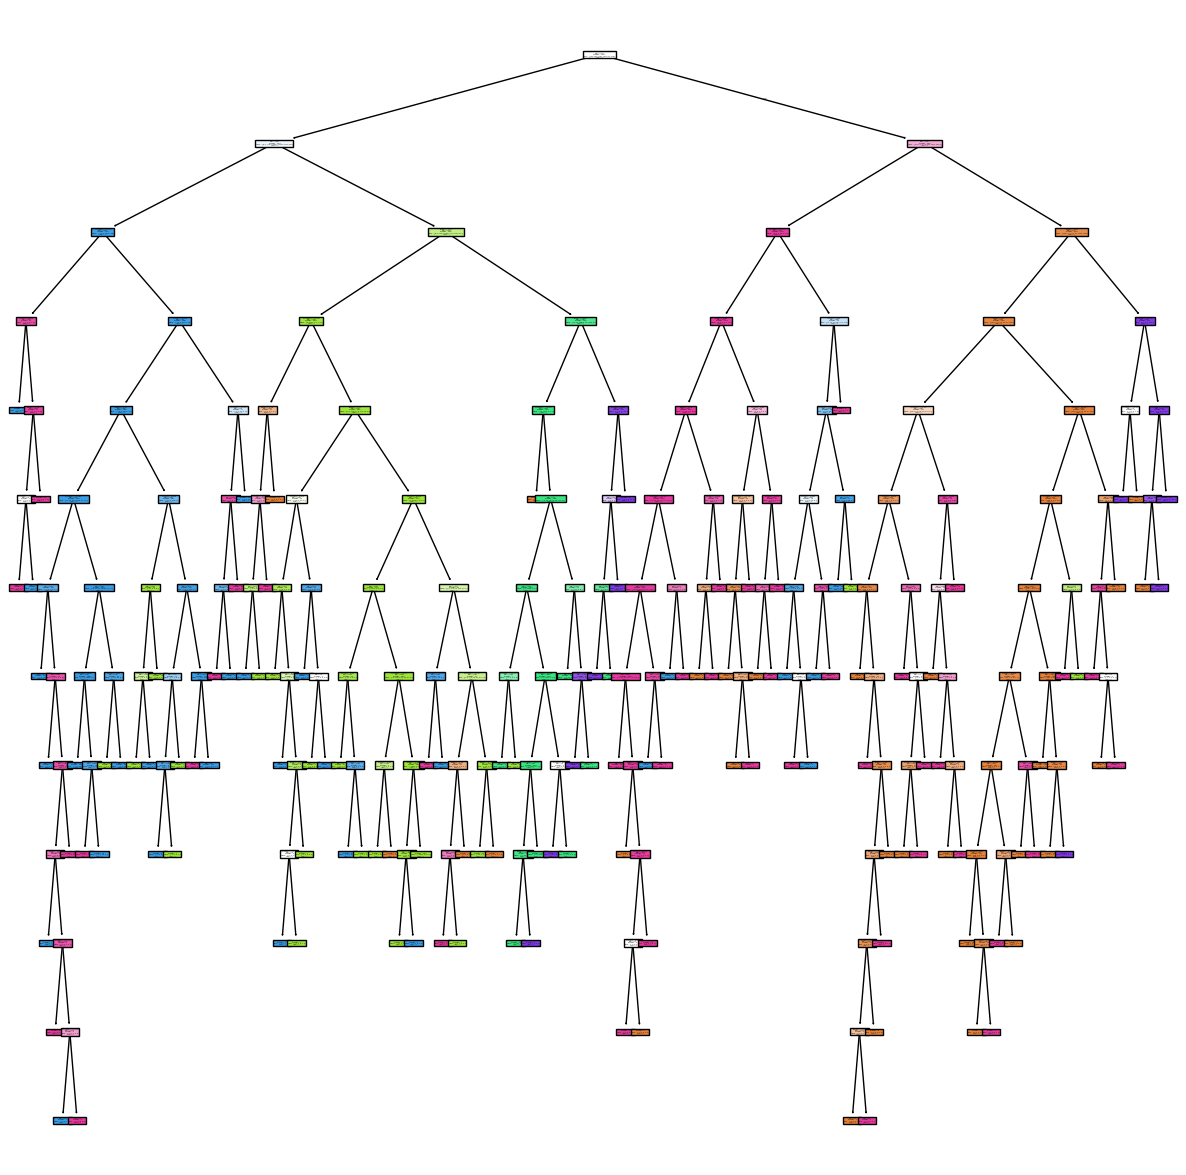

Accuracy del Decision Tree: 0.9941860465116279


In [8]:
y_train = X_train["Cluster"]
X_train_features = X_train.drop("Cluster", axis=1)

y_test = X_test["Cluster"]
X_test_features = X_test.drop("Cluster", axis=1)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_features, y_train)

# Visualizar árbol
plt.figure(figsize=(15,15))
plot_tree(dt_model, feature_names=X_train_features.columns, class_names=[str(i) for i in range(6)], filled=True)
plt.show()

# Evaluar precisión
y_pred = dt_model.predict(X_test_features)
print("Accuracy del Decision Tree:", accuracy_score(y_test, y_pred))

Este flujo es muy común cuando contamos con datos no etiquetados: utilizar un modelo de aprendizaje no supervisado para etiquetarlos de forma automática y a continuación, un modelo de aprendizaje supervisado.

In [9]:
dt_model = DecisionTreeClassifier(
    max_depth=3,        # limita la profundidad del árbol
    random_state=42
)

dt_model.fit(X_train_features, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

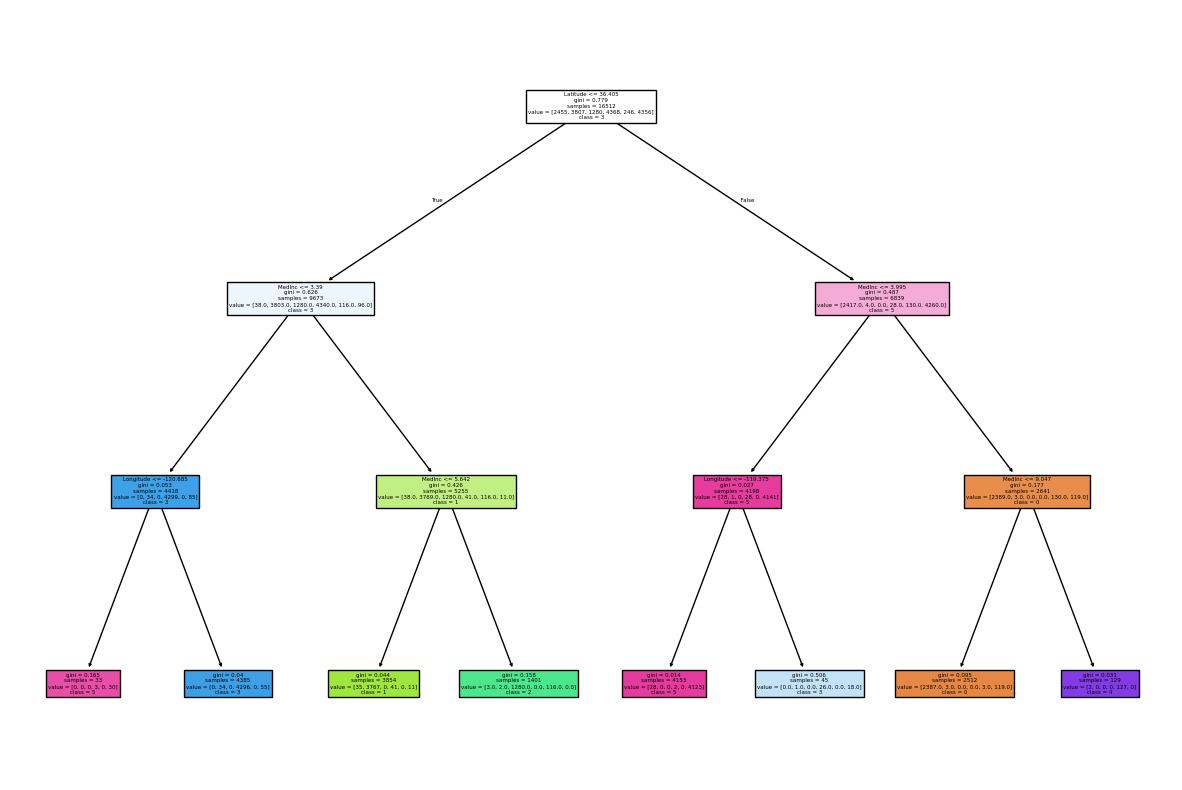

In [10]:
plt.figure(figsize=(15,10))
plot_tree(
    dt_model,
    feature_names=X_train_features.columns,
    class_names=[str(i) for i in range(6)],
    filled=True
)
plt.show()

### Paso 5: Guarda los modelos

Almacena ambos modelos en la carpeta correspondiente.

In [11]:
pickle.dump(kmeans, open("kmeans_model.pkl", "wb"))
pickle.dump(dt_model, open("decision_tree_model.pkl", "wb"))